In [2]:
!pip install diffusers transformers accelerate safetensors torch


In [3]:
import os
os.environ["HF_HOME"] = "E:/huggingface_cache"  # Change to drive with space


In [4]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None,
    cache_dir="E:/huggingface_cache"
)


pipe.to(device)
pipe.enable_attention_slicing()


c:\Users\hp\anaconda3\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\hp\anaconda3\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: E:\huggingface_cache\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For 

  0%|          | 0/25 [00:00<?, ?it/s]

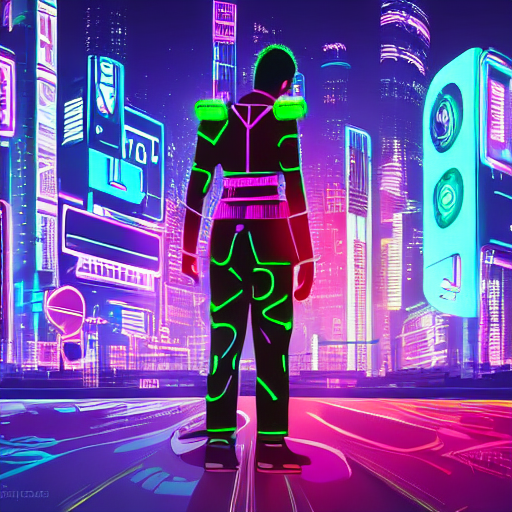

In [5]:
prompt = "A futuristic AI engineer in neon cyberpunk city, ultra detailed"

image = pipe(
    prompt,
    height=512,
    width=512,
    guidance_scale=7.5,
    num_inference_steps=25
).images[0]

image.save("output.png")
image
